In [2]:
using Pkg
# Pkg.dev("../Jyce.jl")
using Jyce
using Plots
using DataFrames
using CSV

In [ ]:
require_native!()
sim = Jyce.XyceSimulator(false)

Jyce.XyceSimulatorAllocated(Ptr{Nothing} @0x000000000a03f960)

In [8]:
vteam_netlist = """
* VTEAM Memristor Plugin Testbench
* Testing Bipolar Switching Behavior

.OPTIONS DEVICE level=2

* --- Signal Source ---
* A sinusoidal input to create a Pinched Hysteresis Loop
* 2.0V amplitude at 1Hz frequency
V1 IN 0 SIN(0 2.0 1)

* --- Custom Memristor Instance ---
* Replace 'mem_plugin' with the actual model name defined in your .so
* Replace 'level' or 'type' with the specific identifier for your plugin
YMEM IN 0 mem_plugin 
+ ron=100 roff=10k 
+ v_on=-0.5 v_off=0.5 
+ k_on=-10 k_off=10 
+ alpha_on=1 alpha_off=1 
+ x_init=0.1

* --- Simulation Settings ---
* Simulate for 2 full cycles (2 seconds)
.TRAN 0.001 2.0

* --- Output Requests ---
.PRINT TRAN V(IN) I(YMEM) 
.PRINT TRAN N(YMEM:state_variable)  * Adjust based on your plugin's internal name

.END
"""

"* VTEAM Memristor Plugin Testbench\n* Testing Bipolar Switching Behavior\n\n.OPTIONS DEVICE level=2\n\n* --- Signal Source ---\n* A sinusoidal input to create a Pinched Hysteresis Loop\n* 2.0V amplitude at 1Hz frequency\nV1 IN 0 SIN(0 2.0 1)\n\n* --- Custom Memristor Instance ---\n" ⋯ 228 bytes ⋯ "\n+ alpha_on=1 alpha_off=1 \n+ x_init=0.1\n\n* --- Simulation Settings ---\n* Simulate for 2 full cycles (2 seconds)\n.TRAN 0.001 2.0\n\n* --- Output Requests ---\n.PRINT TRAN V(IN) I(YMEM) \n.PRINT TRAN N(YMEM:state_variable)  * Adjust based on your plugin's internal name\n\n.END\n"

In [ ]:
# Force a notebook-friendly transient regardless of prior cell order
loaded = Jyce.loadNetlistString(sim, vteam_netlist)
@assert loaded "Failed to load netlist string"

forced_prn = joinpath(pwd(), "plots", "memristor_notebook_vteam.prn")
result = Jyce.runSimulationOutput(sim, forced_prn)
@assert Jyce.simulation_success(result) Jyce.simulation_error_message(result)

prn_file = isfile(forced_prn) ? forced_prn : String(Jyce.simulation_prn_file_path(result))
@assert isfile(prn_file) "Data file not found: $(prn_file)"

data = Jyce.read_simulation_data(prn_file)
cols = Jyce.detect_iv_columns(data)
println("PRN file: ", prn_file)
println("Signals: ", join(Jyce.get_signal_names(data), ", "))
println("Rows: ", nrow(data))
println("Detected voltage_col: ", cols.voltage_col)
println("Detected current_col: ", cols.current_col)

In [3]:
custom_netlist = """
***********************************************
* HP Memristor SPICE Model
* For Transient Analysis only
* created by Zdenek and Dalibor Biolek
***********************************************
* Ron, Roff - Resistance in ON / OFF States
*
* Rinit - Resistance at T=0
*
* D - Width of the thin film
*
* uv - Migration coefficient
*
* p - Parameter of the WINDOW-function for
*     modeling nonlinear boundary conditions
*
* x - W/D Ratio, W is the actual width
*     of the doped area (from 0 to D)
*
***********************************************
.SUBCKT memristor plus minus PARAMS:
+ Ron=100 Roff=16K Rinit=11K D=10N uv=10F p=1

***********************************************
* DIFFERENTIAL EQUATION MODELING *
***********************************************
Gx 0 x value={I(Emem)*uv*Ron/D**2*f(V(x),p)}
Cx x 0 1 IC={(Roff-Rinit)/(Roff-Ron)}
Raux x 0 1000000

***********************************************
* RESISTIVE PORT OF THE MEMRISTOR *
***********************************************
Emem plus aux value={-I(Emem)*V(x)*(Roff-Ron)}
Roff aux minus {Roff}

***********************************************
* FLUX COMPUTATION *
***********************************************
Eflux flux 0 value={SDT(V(plus,minus))}

***********************************************
* CHARGE COMPUTATION *
***********************************************
Echarge charge 0 value={SDT(I(Emem))}

***********************************************
* WINDOW FUNCTIONS
* FOR NONLINEAR DRIFT MODELING *
***********************************************
* window function, according to Joglekar
.func f(x,p) {1-(2*x-1)**(2*p)}

.ENDS memristor


XMemristor N001 0 memristor
V1 N001 0 SIN(0V 1.2V 1Hz)

* Analysis Command
.TRAN .01ns 3s
* Output
.PRINT TRAN V(N001) I(V1)

.end
"""

"***********************************************\n* HP Memristor SPICE Model\n* For Transient Analysis only\n* created by Zdenek and Dalibor Biolek\n***********************************************\n* Ron, Roff - Resistance in ON / OFF States\n*\n* Rinit - Resistance at T=0\n*\n* " ⋯ 1212 bytes ⋯ "**********************************************\n* window function, according to Joglekar\n.func f(x,p) {1-(2*x-1)**(2*p)}\n\n.ENDS memristor\n\n\nXMemristor N001 0 memristor\nV1 N001 0 SIN(0V 1.2V 1Hz)\n\n* Analysis Command\n.TRAN .01ns 3s\n* Output\n.PRINT TRAN V(N001) I(V1)\n\n.end\n"

In [4]:
# Notebook-friendly transient step for interactive plotting
if @isdefined(custom_netlist)
    custom_netlist = replace(custom_netlist, ".TRAN .01ns 3s" => ".TRAN 1ms 3s")
else
    @warn "Run Cell 3 first to define custom_netlist"
end

"***********************************************\n* HP Memristor SPICE Model\n* For Transient Analysis only\n* created by Zdenek and Dalibor Biolek\n***********************************************\n* Ron, Roff - Resistance in ON / OFF States\n*\n* Rinit - Resistance at T=0\n*\n* " ⋯ 1210 bytes ⋯ "\n***********************************************\n* window function, according to Joglekar\n.func f(x,p) {1-(2*x-1)**(2*p)}\n\n.ENDS memristor\n\n\nXMemristor N001 0 memristor\nV1 N001 0 SIN(0V 1.2V 1Hz)\n\n* Analysis Command\n.TRAN 1ms 3s\n* Output\n.PRINT TRAN V(N001) I(V1)\n\n.end\n"

In [5]:
gr()
mkpath("plots")
println("Using Jyce built-in utils for data reading and plotting")

Using Jyce built-in utils for data reading and plotting


In [6]:
# Force a notebook-friendly transient regardless of prior cell order
netlist_for_run = replace(custom_netlist, ".TRAN .01ns 3s" => ".TRAN 2ms 2s")

loaded = Jyce.loadNetlistString(sim, netlist_for_run)
@assert loaded "Failed to load netlist string"

forced_prn = joinpath(pwd(), "plots", "memristor_notebook.prn")
result = Jyce.runSimulationOutput(sim, forced_prn)
@assert Jyce.simulation_success(result) Jyce.simulation_error_message(result)

prn_file = isfile(forced_prn) ? forced_prn : String(Jyce.simulation_prn_file_path(result))
@assert isfile(prn_file) "Data file not found: $(prn_file)"

data = Jyce.read_simulation_data(prn_file)
cols = Jyce.detect_iv_columns(data)
println("PRN file: ", prn_file)
println("Signals: ", join(Jyce.get_signal_names(data), ", "))
println("Rows: ", nrow(data))
println("Detected voltage_col: ", cols.voltage_col)
println("Detected current_col: ", cols.current_col)


*****
***** Welcome to the Xyce(TM) Parallel Electronic Simulator
*****
***** This is version XyceNF Release 7.10.0
***** Date: Sun Apr 12 11:44:47 AM CEST 2026


***** Executing netlist /tmp/xyce_netlist_4693217401654225338.cir

***** Reading and parsing netlist...
***** Setting up topology...

Netlist warning: Voltage Node (XMEMRISTOR:FLUX) connected to only 1 device
 Terminal
Netlist warning: Voltage Node (XMEMRISTOR:CHARGE) connected to only 1 device
 Terminal
***** Device Count Summary ...
       B level 1 (Expression Based Voltage or Current Source) 4
       C level 1 (Capacitor)                                  1
       R level 1 (Resistor)                                   2
       V level 1 (Independent Voltage Source)                 1
       --------------------------------------------------------
       Total Devices                                          8
***** Setting up matrix structure...
***** Number of Unknowns = 10
***** Initializing...

***** Beginning DC Operat

Saved transient plot: /home/daris/Documents/workspace/memristor_proj/Jyce_Examples/plots/memristor_transient.png


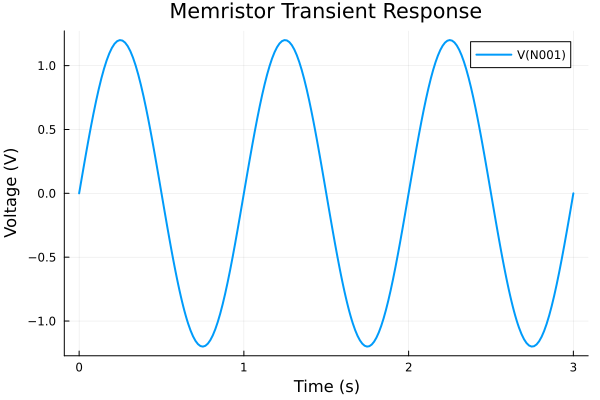

In [7]:
plot_dir = dirname(String(prn_file))
mkpath(plot_dir)
transient_png = joinpath(plot_dir, "memristor_transient.png")

transient_plot = Jyce.plot_transient_voltages(
    prn_file;
    nodes=["V(N001)"],
    output_file=transient_png,
    title="Memristor Transient Response"
 )
println("Saved transient plot: ", transient_png)
display(transient_plot)

Saved I-V plot: /home/daris/Documents/workspace/memristor_proj/Jyce_Examples/plots/memristor_iv.png


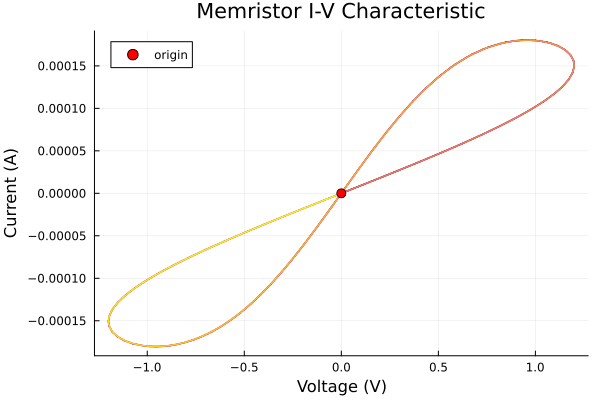

In [8]:
plot_dir = dirname(String(prn_file))
mkpath(plot_dir)
iv_png = joinpath(plot_dir, "memristor_iv.png")

iv_plot = Jyce.plot_iv_characteristic(
    prn_file;
    voltage_col=cols.voltage_col,
    current_col=cols.current_col,
    output_file=iv_png,
    title="Memristor I-V Characteristic",
    cycle_overlay=true
 )
println("Saved I-V plot: ", iv_png)
display(iv_plot)


*****
***** Welcome to the Xyce(TM) Parallel Electronic Simulator
*****
***** This is version XyceNF Release 7.10.0
***** Date: Sun Apr 12 11:47:02 AM CEST 2026


***** Executing netlist /tmp/xyce_netlist_7249037722869985651.cir

***** Reading and parsing netlist...
***** Setting up topology...

***** Device Count Summary ...
       R level 1 (Resistor)                   2
       V level 1 (Independent Voltage Source) 1
       ----------------------------------------
       Total Devices                          3
***** Setting up matrix structure...
***** Number of Unknowns = 3
***** Initializing...

***** Beginning DC Operating Point Calculation...

***** Beginning Transient Calculation...

***** Percent complete: 1.03699 %
***** Current system time: Sun 12 Apr 2026 11:47:02 AM CEST
***** Estimated time to completion:  0 sec.

***** Percent complete: 2.09247 %
***** Current system time: Sun 12 Apr 2026 11:47:02 AM CEST
***** Estimated time to completion:  0 sec.

***** Percent compl

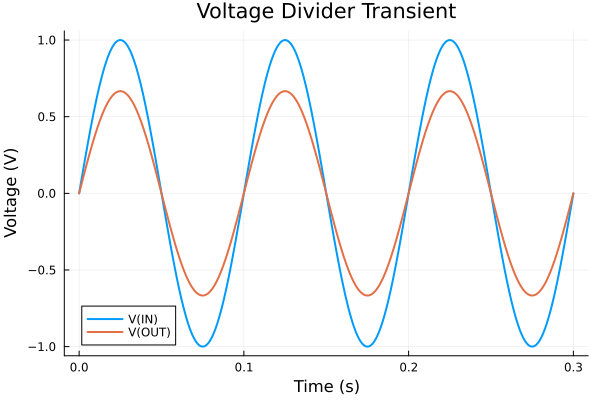

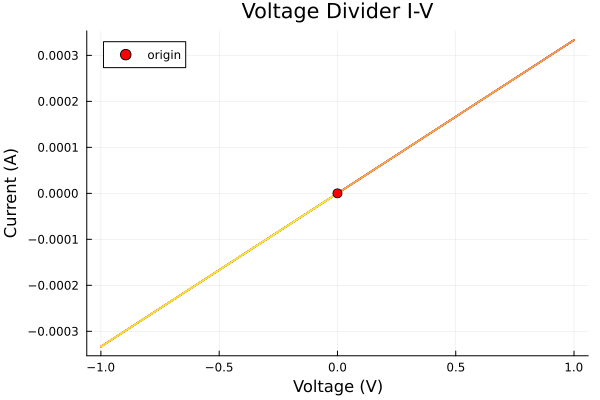

In [12]:
divider_netlist = """
* Voltage divider example
V1 in 0 SIN(0 1 10)
R1 in out 1k
R2 out 0 2k
.TRAN 1ms 300ms
.PRINT TRAN V(in) V(out) I(V1)
.END
"""

@assert Jyce.loadNetlistString(sim, divider_netlist)
divider_prn = joinpath(pwd(), "plots", "divider.prn")
divider_result = Jyce.runSimulationOutput(sim, divider_prn)
@assert Jyce.simulation_success(divider_result) Jyce.simulation_error_message(divider_result)

divider_data = Jyce.read_simulation_data(divider_prn)
divider_cols = Jyce.detect_iv_columns(divider_data)
println("Divider detected columns -> V: ", divider_cols.voltage_col, ", I: ", divider_cols.current_col)

divider_tr = Jyce.plot_transient_voltages(
    divider_prn;
    nodes=["V(IN)", "V(OUT)"],
    output_file=joinpath(pwd(), "plots", "divider_transient.png"),
    title="Voltage Divider Transient"
 )
display(divider_tr)

divider_iv = Jyce.plot_iv_characteristic(
    divider_prn;
    voltage_col=divider_cols.voltage_col,
    current_col=divider_cols.current_col,
    output_file=joinpath(pwd(), "plots", "divider_iv.png"),
    title="Voltage Divider I-V",
    cycle_overlay=true
 )
display(divider_iv)


*****
***** Welcome to the Xyce(TM) Parallel Electronic Simulator
*****
***** This is version XyceNF Release 7.10.0
***** Date: Sun Apr 12 11:47:28 AM CEST 2026


***** Executing netlist /tmp/xyce_netlist_7594484593173362813.cir

***** Reading and parsing netlist...
***** Setting up topology...

***** Device Count Summary ...
       C level 1 (Capacitor)                  1
       R level 1 (Resistor)                   1
       V level 1 (Independent Voltage Source) 1
       ----------------------------------------
       Total Devices                          3
***** Setting up matrix structure...
***** Number of Unknowns = 3
***** Initializing...

***** Beginning DC Operating Point Calculation...

***** Beginning Transient Calculation...

***** Percent complete: 1.06376 %
***** Current system time: Sun 12 Apr 2026 11:47:28 AM CEST
***** Estimated time to completion:  0 sec.

***** Percent complete: 2.26184 %
***** Current system time: Sun 12 Apr 2026 11:47:28 AM CEST
***** Estimated 

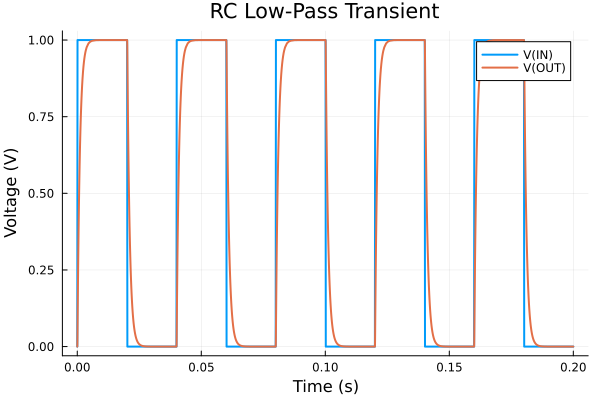

In [14]:
rc_netlist = """
* RC low-pass filter transient
V1 in 0 PULSE(0 1 0 100us 100us 20ms 40ms)
R1 in out 1k
C1 out 0 1u
.TRAN 100us 200ms
.PRINT TRAN V(in) V(out) I(V1)
.END
"""

@assert Jyce.loadNetlistString(sim, rc_netlist)
rc_prn = joinpath(pwd(), "plots", "rc_filter.prn")
rc_result = Jyce.runSimulationOutput(sim, rc_prn)
@assert Jyce.simulation_success(rc_result) Jyce.simulation_error_message(rc_result)

rc_data = Jyce.read_simulation_data(rc_prn)
rc_cols = Jyce.detect_iv_columns(rc_data)
println("RC detected columns -> V: ", rc_cols.voltage_col, ", I: ", rc_cols.current_col)
println("RC columns: ", join(rc_cols.available_columns, ", "))

rc_tr = Jyce.plot_transient_voltages(
    rc_prn;
    nodes=["V(IN)", "V(OUT)"],
    output_file=joinpath(pwd(), "plots", "rc_transient.png"),
    title="RC Low-Pass Transient"
 )
display(rc_tr)